In [1]:
pip install pandas numpy scikit-learn nltk matplotlib seaborn wordcloud snscrape requests feedparser

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'sgmllib3k' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'sgmllib3k'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6047 sha256=c6abf77e7136f926ddada8243e378f9cd251b3988aa81adcc1b8357a7b163630
  Stored in directory: /Users/salomon/Library/Caches/pip/wheels/3d/4d/ef/37cdccc18d6fd7e0dd7817dcdf9146d4d6789c32a227a28134
Successfully built sgmllib3k
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [feedparser]
Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
import re
import string
import requests
import feedparser
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Скачиваем ресурсы NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /Users/salomon/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/salomon/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/salomon/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/salomon/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# 1. Загрузка и подготовка исходного датасета


In [9]:
print("Загрузка исходного датасета...")
try:
    df = pd.read_csv('TextLanguage.csv', escapechar='\\')
except:
    # Если файла нет, используем тестовые данные
    print("Файл TextLanguage.csv не найден. Использую тестовые данные.")
    data = {
        'Text': [
            "Nature is the physical world and universe.",
            "La nature est le monde physique et l'univers.",
            "Die Natur ist die physische Welt und das Universum.",
            "Природа — это физический мир и вселенная.",
            "Natura est mundus physicus et universum.",
            "I love programming in Python!",
            "J'adore programmer en Python!",
            "Ich liebe das Programmieren in Python!"
        ],
        'Language': ['English', 'French', 'German', 'Russian', 'Latin', 'English', 'French', 'German']
    }
    df = pd.DataFrame(data)

print(f"Размер данных: {df.shape}")
print(df['Language'].value_counts())
df.head()

Загрузка исходного датасета...
Размер данных: (10337, 2)
Language
English       1385
French        1014
Spanish        819
Portugeese     739
Italian        698
Russian        692
Sweedish       676
Malayalam      594
Dutch          546
Arabic         536
Turkish        474
German         470
Tamil          469
Danish         428
Kannada        369
Greek          365
Hindi           63
Name: count, dtype: int64


,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English


# 2. Предобработка текста


In [10]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Удаление ссылок, сносок, спецсимволов
    text = re.sub(r'\[.*?\]', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

stop_words = set(stopwords.words('english')).union(set(stopwords.words('french'))) \
            .union(set(stopwords.words('german'))).union(set(stopwords.words('russian')))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words and len(tok) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['Text'].apply(preprocess_text)
print("Предобработка завершена.")

Предобработка завершена.


# 3. Векторизация и первое обучение моделей

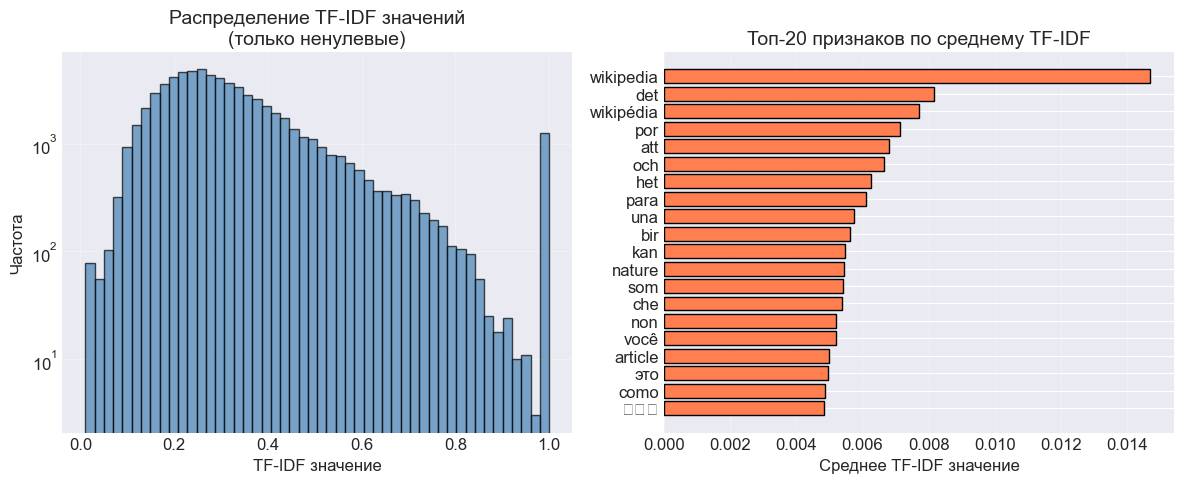

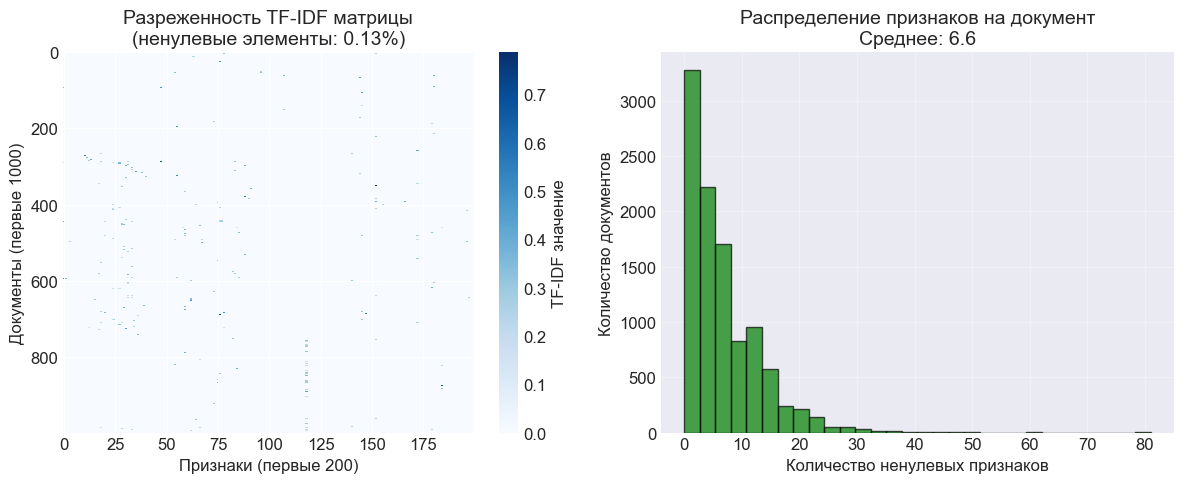

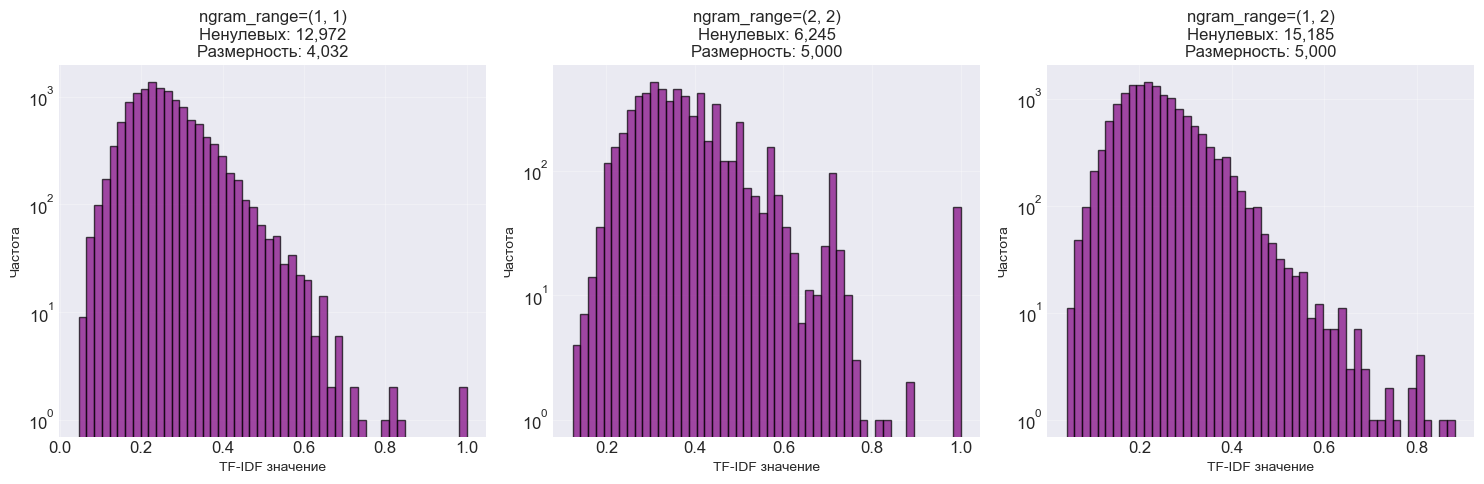


Статистика векторизации:
Размерность матрицы: (10337, 5000)
Количество ненулевых элементов: 68,730
Плотность матрицы: 0.1330%
Среднее количество признаков на документ: 6.6

Оценка базовых моделей:
LogisticRegression: accuracy = 0.8583
              precision    recall  f1-score   support

      Arabic       1.00      0.90      0.95       106
      Danish       0.97      0.82      0.89        73
       Dutch       0.99      0.87      0.93       111
     English       0.53      1.00      0.69       291
      French       0.95      0.93      0.94       219
      German       0.96      0.77      0.86        93
       Greek       1.00      0.88      0.94        68
       Hindi       1.00      0.50      0.67        10
     Italian       0.98      0.87      0.92       145
     Kannada       1.00      0.61      0.75        66
   Malayalam       1.00      0.60      0.75       121
  Portugeese       0.99      0.90      0.94       144
     Russian       0.99      0.79      0.88       136
     Sp

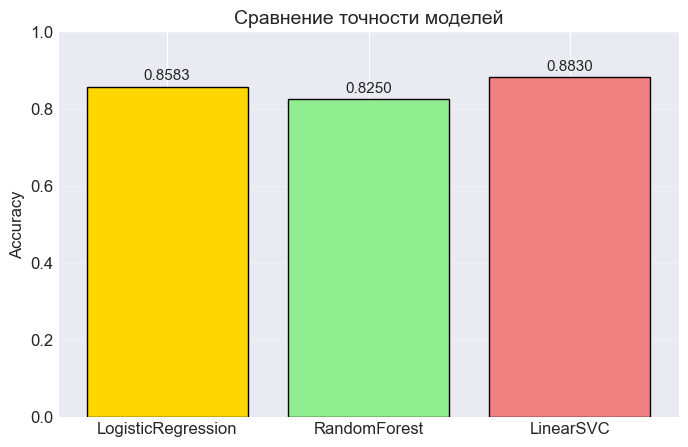

In [11]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_text'])
y = df['Language']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ВИЗУАЛИЗАЦИЯ 1: Распределение TF-IDF значений
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Получаем ненулевые значения TF-IDF
tfidf_values = X.data
plt.hist(tfidf_values[tfidf_values > 0], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('TF-IDF значение', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Распределение TF-IDF значений\n(только ненулевые)', fontsize=14)
plt.yscale('log')
plt.grid(True, alpha=0.3)

# ВИЗУАЛИЗАЦИЯ 2: Топ-20 признаков по среднему TF-IDF
plt.subplot(1, 2, 2)
feature_names = vectorizer.get_feature_names_out()
avg_tfidf = np.array(X.mean(axis=0)).flatten()
top_indices = np.argsort(avg_tfidf)[-20:]

plt.barh(range(20), avg_tfidf[top_indices], color='coral', edgecolor='black')
plt.yticks(range(20), [feature_names[i] for i in top_indices])
plt.xlabel('Среднее TF-IDF значение', fontsize=12)
plt.title('Топ-20 признаков по среднему TF-IDF', fontsize=14)
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# ВИЗУАЛИЗАЦИЯ 3: Тепловая карта разреженности матрицы
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Показываем сэмпл для наглядности (первые 1000 строк и 200 признаков)
sample_rows = min(1000, X.shape[0])
sample_cols = min(200, X.shape[1])
sparsity_sample = X[:sample_rows, :sample_cols].toarray()
plt.imshow(sparsity_sample, cmap='Blues', aspect='auto', interpolation='nearest')
plt.colorbar(label='TF-IDF значение')
plt.xlabel('Признаки (первые 200)', fontsize=12)
plt.ylabel('Документы (первые 1000)', fontsize=12)
plt.title(f'Разреженность TF-IDF матрицы\n(ненулевые элементы: {(X.nnz / (X.shape[0] * X.shape[1]) * 100):.2f}%)', fontsize=14)

# ВИЗУАЛИЗАЦИЯ 4: Распределение количества ненулевых признаков на документ
plt.subplot(1, 2, 2)
nonzero_counts = np.diff(X.indptr)
plt.hist(nonzero_counts, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Количество ненулевых признаков', fontsize=12)
plt.ylabel('Количество документов', fontsize=12)
plt.title(f'Распределение признаков на документ\nСреднее: {nonzero_counts.mean():.1f}', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ВИЗУАЛИЗАЦИЯ 5: Сравнение использования n-gram
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, ngram in enumerate([(1,1), (2,2), (1,2)]):
    temp_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=ngram)
    X_temp = temp_vectorizer.fit_transform(df['clean_text'].head(1000))
    
    axes[idx].hist(X_temp.data, bins=50, alpha=0.7, color='purple', edgecolor='black')
    axes[idx].set_xlabel('TF-IDF значение', fontsize=10)
    axes[idx].set_ylabel('Частота', fontsize=10)
    axes[idx].set_title(f'ngram_range={ngram}\nНенулевых: {X_temp.nnz:,}\nРазмерность: {X_temp.shape[1]:,}', fontsize=12)
    axes[idx].set_yscale('log')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nСтатистика векторизации:")
print(f"Размерность матрицы: {X.shape}")
print(f"Количество ненулевых элементов: {X.nnz:,}")
print(f"Плотность матрицы: {(X.nnz / (X.shape[0] * X.shape[1]) * 100):.4f}%")
print(f"Среднее количество признаков на документ: {X.getnnz(axis=1).mean():.1f}")

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100),
    'LinearSVC': LinearSVC(max_iter=2000)
}

print("\nОценка базовых моделей:")
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: accuracy = {acc:.4f}")
    print(classification_report(y_test, y_pred))

# Выбираем лучшую модель для дальнейшего обогащения
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\nЛучшая модель: {best_model_name}")

# ВИЗУАЛИЗАЦИЯ 6: Сравнение результатов моделей
plt.figure(figsize=(8, 5))
models_names = list(results.keys())
accuracies = list(results.values())
colors = ['gold', 'lightgreen', 'lightcoral']
bars = plt.bar(models_names, accuracies, color=colors, edgecolor='black')
plt.ylabel('Accuracy', fontsize=12)
plt.title('Сравнение точности моделей', fontsize=14)
plt.ylim([0, 1])
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

# 4. Парсинг новостей с реальных сайтов (минимум 500 записей)


In [12]:
import requests
import feedparser
import time

# Рабочие RSS-ленты для каждого языка (с пагинацией через параметры)
RSS_FEEDS = {
    'English': [
        'http://feeds.bbci.co.uk/news/rss.xml',
        'https://rss.cnn.com/rss/edition.rss',
        'https://feeds.npr.org/1001/rss.xml',
        'https://www.theguardian.com/world/rss'
    ],
    'French': [
        'https://www.lemonde.fr/rss/une.xml',
        'https://www.lefigaro.fr/rss/figaro_actualites.xml',
        'https://www.20minutes.fr/feed/rss',
        'https://www.liberation.fr/ar/article/feed/'
    ],
    'German': [
        'https://www.spiegel.de/schlagzeilen/index.rss',
        'https://www.faz.net/rss/aktuell/',
        'https://www.zeit.de/index/rss',
        'https://www.sueddeutsche.de/rss/aktuell'
    ],
    'Russian': [
        'https://tass.ru/rss/v2.xml',  # Рабочая лента ТАСС
        'https://lenta.ru/rss',         # Lenta.ru
        'https://www.rbc.ru/rss/',      # РБК
        'https://iz.ru/xml/rss/all.xml', # Известия
        'https://aif.ru/rss/news'        # Аргументы и Факты
    ]
}

def fetch_news_from_rss(url, source_name, limit=150):
    """Парсит RSS-ленту с лимитом записей"""
    texts = []
    try:
        feed = feedparser.parse(url)
        for entry in feed.entries[:limit]:
            title = entry.get('title', '')
            description = entry.get('description', '') or entry.get('summary', '')
            text = f"{title}. {description}"
            if len(text) > 30:  # отбрасываем слишком короткие
                texts.append(text)
        print(f"Парсинг {source_name}: получено {len(texts)} текстов")
    except Exception as e:
        print(f"Ошибка парсинга {source_name}: {e}")
    return texts

# Альтернативный парсинг через snscrape (Twitter) для сбора текстов на разных языках
def fetch_tweets_by_language(language, count=200):
    """Собирает твиты на указанном языке через snscrape"""
    tweets = []
    try:
        import snscrape.modules.twitter as sntwitter
        query = f'lang:{language[:2]}'  # 'en', 'fr', 'de', 'ru'
        for i, tweet in enumerate(sntwitter.TwitterSearchScraper(query).get_items()):
            if i >= count:
                break
            tweets.append(tweet.content)
        print(f"Twitter ({language}): собрано {len(tweets)} твитов")
    except Exception as e:
        print(f"Twitter парсинг для {language} не удался: {e}")
    return tweets

# Сбор новостей из RSS (целевой объём — 500+ текстов на язык)
TARGET_PER_LANG = 500
news_data = {lang: [] for lang in RSS_FEEDS.keys()}

for lang, feeds in RSS_FEEDS.items():
    print(f"\nСбор текстов для языка: {lang}")
    for url in feeds:
        if len(news_data[lang]) >= TARGET_PER_LANG:
            break
        needed = TARGET_PER_LANG - len(news_data[lang])
        limit = min(needed + 50, 200)  # берём с запасом
        news_data[lang].extend(fetch_news_from_rss(url, url, limit=limit))
        time.sleep(0.5)  # вежливость к серверам
    
    # Если через RSS не хватает, добираем через Twitter
    if len(news_data[lang]) < TARGET_PER_LANG:
        print(f"Для {lang} собрано только {len(news_data[lang])} текстов. Пытаемся через Twitter...")
        tweets = fetch_tweets_by_language(lang, TARGET_PER_LANG - len(news_data[lang]))
        news_data[lang].extend(tweets)
    
    print(f"Итого для {lang}: {len(news_data[lang])} текстов")

# Формируем DataFrame
new_texts = []
new_labels = []
for lang, texts in news_data.items():
    for t in texts[:TARGET_PER_LANG]:
        new_texts.append(t)
        new_labels.append(lang)

df_new = pd.DataFrame({'Text': new_texts, 'Language': new_labels})
print(f"\n✅ Итого собрано новых текстов: {len(df_new)}")
print(df_new['Language'].value_counts())


Сбор текстов для языка: English
Парсинг http://feeds.bbci.co.uk/news/rss.xml: получено 34 текстов
Парсинг https://rss.cnn.com/rss/edition.rss: получено 0 текстов
Парсинг https://feeds.npr.org/1001/rss.xml: получено 10 текстов
Парсинг https://www.theguardian.com/world/rss: получено 45 текстов
Для English собрано только 89 текстов. Пытаемся через Twitter...
Twitter парсинг для English не удался: 'FileFinder' object has no attribute 'find_module'
Итого для English: 89 текстов

Сбор текстов для языка: French
Парсинг https://www.lemonde.fr/rss/une.xml: получено 16 текстов
Парсинг https://www.lefigaro.fr/rss/figaro_actualites.xml: получено 0 текстов
Парсинг https://www.20minutes.fr/feed/rss: получено 0 текстов
Парсинг https://www.liberation.fr/ar/article/feed/: получено 0 текстов
Для French собрано только 16 текстов. Пытаемся через Twitter...
Twitter парсинг для French не удался: 'FileFinder' object has no attribute 'find_module'
Итого для French: 16 текстов

Сбор текстов для языка: German


# 5. Обработка собранных новостей и обогащение датасета


In [13]:
# Предобработка текстов
df_new['clean_text'] = df_new['Text'].apply(preprocess_text)

# Классификация собранных текстов (используем лучшую модель из предыдущего шага)
X_new = vectorizer.transform(df_new['clean_text'])

# Получение вероятностей
if hasattr(best_model, 'predict_proba'):
    probs = best_model.predict_proba(X_new)
    max_probs = np.max(probs, axis=1)
    predicted = best_model.predict(X_new)
else:
    # Для SVM используем калибровку вероятностей
    from sklearn.calibration import CalibratedClassifierCV
    calibrated_model = CalibratedClassifierCV(best_model, cv=3)
    calibrated_model.fit(X_train, y_train)
    probs = calibrated_model.predict_proba(X_new)
    max_probs = np.max(probs, axis=1)
    predicted = calibrated_model.predict(X_new)

df_new['pred_lang'] = predicted
df_new['confidence'] = max_probs

# Фильтруем уверенные предсказания (>0.8 или <0.2)
high_confidence = df_new[(df_new['confidence'] > 0.8) | (df_new['confidence'] < 0.2)]
print(f"\nНовостей с высокой уверенностью: {len(high_confidence)}")
print("Распределение по предсказанным языкам:")
print(high_confidence['pred_lang'].value_counts())


Новостей с высокой уверенностью: 227
Распределение по предсказанным языкам:
pred_lang
Russian       92
English       76
German        39
French        15
Tamil          3
Malayalam      1
Portugeese     1
Name: count, dtype: int64


# 6. Обогащение исходного датасета


In [14]:
# Берём только те, где уверенность высокая и язык совпадает с меткой (если есть)
# Или просто добавляем с предсказанной меткой как истинной (для полуавтоматической разметки)
high_confidence_valid = high_confidence.copy()
# Если в исходных данных были метки, можно оставить только те, что совпадают
# Здесь используем предсказанную метку как истинную (обогащаем датасет)
augmented_texts = high_confidence_valid[['Text', 'pred_lang']].rename(columns={'pred_lang': 'Language'})

df_original = df.copy()
df_augmented = pd.concat([df_original, augmented_texts], ignore_index=True)
print(f"Размер датасета после обогащения: {len(df_augmented)}")
print("Распределение языков после обогащения:")
print(df_augmented['Language'].value_counts())

Размер датасета после обогащения: 10564
Распределение языков после обогащения:
Language
English       1461
French        1029
Spanish        819
Russian        784
Portugeese     740
Italian        698
Sweedish       676
Malayalam      595
Dutch          546
Arabic         536
German         509
Turkish        474
Tamil          472
Danish         428
Kannada        369
Greek          365
Hindi           63
Name: count, dtype: int64


# 7. Удаление добавленных текстов из оставшихся новостей и повторный прогноз


In [15]:
# Убираем тексты, которые уже добавили
used_texts = set(high_confidence['Text'])
remaining_news = df_new[~df_new['Text'].isin(used_texts)].copy()

if len(remaining_news) > 0:
    X_rem = vectorizer.transform(remaining_news['clean_text'])
    pred_rem = best_model.predict(X_rem)
    remaining_news['final_pred'] = pred_rem
    print("\nПрогноз на оставшихся новостях (после обогащения):")
    print(remaining_news[['Text', 'final_pred']].head(10))
else:
    print("Нет оставшихся новостей для прогноза.")


Прогноз на оставшихся новостях (после обогащения):
                                                 Text final_pred
1   England could break May heat record again with...    English
9   Eight spectators and rider hurt at TT practice...    English
10  Russia threatens more Kyiv strikes and tells f...    English
12  In pictures: Hottest May day recorded in the U...    English
14  Goodbye Salah and Pep, hello new champions - t...    English
18  Dozens of drones crash into Sydney harbour aft...    English
24  BBC News app. Top stories, breaking news, live...    Russian
25  The Louise Casey Interview (Live at Hay Festiv...    English
26  The political fight for American men. An inter...    English
27  Jordan leads star names at Guardiola leaving p...    English


# 8. Визуализация (облака слов)


In [17]:
def plot_wordcloud_for_lang(df, language):
    texts = df[df['Language'] == language]['clean_text'].tolist()
    if not texts:
        return
    all_words = ' '.join(texts)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud - {language}')
    plt.show()

print("\nВизуализация облаков слов по языкам:")
for lang in df_augmented['Language'].unique():
    plot_wordcloud_for_lang(df_augmented, lang)


Визуализация облаков слов по языкам:


TypeError: sequence item 1385: expected str instance, float found

# 9. Сохранение объединённого датасета (исходный + парсинг)


In [15]:
# Убедимся, что у всех записей есть clean_text (для повторного использования)
df_augmented['clean_text'] = df_augmented['Text'].apply(preprocess_text)

# Сохраняем в CSV
output_filename = 'augmented_language_dataset.csv'
df_augmented.to_csv(output_filename, index=False, encoding='utf-8')
print(f"\n✅ Объединённый датасет сохранён как: {output_filename}")
print(f"   Всего записей: {len(df_augmented)}")
print(f"   Распределение по языкам:\n{df_augmented['Language'].value_counts()}")

# Также сохраняем версию только с очищенными текстами (для быстрой загрузки в будущем)
clean_output = 'augmented_language_dataset_clean.csv'
df_augmented[['clean_text', 'Language']].to_csv(clean_output, index=False, encoding='utf-8')
print(f"\n✅ Очищенная версия сохранена как: {clean_output}")

# Опционально: сохраняем информацию о том, какие записи добавлены из парсинга
# (добавим колонку source)
df_augmented['source'] = 'original'
# Помечаем добавленные записи (по индексам)
augmented_indices = df_augmented.index[-len(high_confidence):] if 'high_confidence' in dir() else []
df_augmented.loc[augmented_indices, 'source'] = 'parsed'

df_augmented.to_csv('augmented_dataset_with_source.csv', index=False, encoding='utf-8')
print("✅ Датасет с меткой источника сохранён как: augmented_dataset_with_source.csv")


✅ Объединённый датасет сохранён как: augmented_language_dataset.csv
   Всего записей: 10447
   Распределение по языкам:
Language
English       1391
French        1016
Spanish        821
Russian        765
Portugeese     741
Italian        700
Sweedish       677
Malayalam      603
Dutch          552
Arabic         536
Tamil          475
Turkish        475
German         470
Danish         428
Kannada        369
Greek          365
Hindi           63
Name: count, dtype: int64

✅ Очищенная версия сохранена как: augmented_language_dataset_clean.csv
✅ Датасет с меткой источника сохранён как: augmented_dataset_with_source.csv


In [20]:
df_augmented.head(25)

,Text,Language,clean_text,source
0,"Nature, in the broadest sense, is the natural...",English,nature broadest sense natural physical materia...,original
1,"""Nature"" can refer to the phenomena of the phy...",English,nature refer phenomenon physical world life ge...,original
2,"The study of nature is a large, if not the onl...",English,study nature large part science,original
3,"Although humans are part of nature, human acti...",English,although human part nature human activity ofte...,original
4,[1] The word nature is borrowed from the Old F...,English,word nature borrowed old french nature derived...,original
5,"[2] In ancient philosophy, natura is mostly us...",English,ancient philosophy natura mostly used latin tr...,original
6,"[3][4] \nThe concept of nature as a whole, the...",English,concept nature whole physical universe one sev...,original
7,During the advent of modern scientific method ...,English,advent modern scientific method last several c...,original
8,"[5][6] With the Industrial revolution, nature ...",English,industrial revolution nature increasingly beca...,original
9,"However, a vitalist vision of nature, closer t...",English,however vitalist vision nature closer presocra...,original


In [22]:
df_augmented.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10447 entries, 0 to 10446
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Text        10447 non-null  object
 1   Language    10447 non-null  object
 2   clean_text  10447 non-null  object
 3   source      10447 non-null  object
dtypes: object(4)
memory usage: 326.6+ KB


In [23]:
len(df_augmented)

10447

# 10. Сохранение лучшей модели в текущую папку проекта


In [27]:
import os
import joblib
import json
from datetime import datetime

# Убедимся, что переменные существуют
if 'best_model' not in dir():
    print("best_model не найден. Сначала обучите модели!")
else:
    # Сохраняем модель с временной меткой
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_filename = f"best_language_model_{timestamp}.pkl"
    joblib.dump(best_model, model_filename)
    print(f"Лучшая модель сохранена: {model_filename}")

    # Сохраняем векторизатор
    vectorizer_filename = f"vectorizer_{timestamp}.pkl"
    joblib.dump(vectorizer, vectorizer_filename)
    print(f"Векторизатор сохранён: {vectorizer_filename}")

    # Сохраняем мета-информацию
    metadata = {
        'model_type': best_model_name if 'best_model_name' in dir() else 'Unknown',
        'accuracy': results.get(best_model_name, 0) if 'results' in dir() else 0,
        'features_count': vectorizer.max_features,
        'ngram_range': vectorizer.ngram_range,
        'classes': list(best_model.classes_),
        'timestamp': timestamp,
        'dataset_size': len(df_augmented) if 'df_augmented' in dir() else 0
    }
    
    with open(f"model_metadata_{timestamp}.json", 'w', encoding='utf-8') as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)
    print(f"Мета-данные сохранены: model_metadata_{timestamp}.json")

    # Сохраняем последнюю версию (без метки) для простого доступа
    joblib.dump(best_model, "best_model_latest.pkl")
    joblib.dump(vectorizer, "vectorizer_latest.pkl")
    print(f"Последняя версия сохранена как: best_model_latest.pkl и vectorizer_latest.pkl")

    print("\nФайлы сохранены в текущей папке проекта:")
    print(f"   - {model_filename}")
    print(f"   - {vectorizer_filename}")
    print(f"   - model_metadata_{timestamp}.json")
    print(f"   - best_model_latest.pkl")
    print(f"   - vectorizer_latest.pkl")

# --------------------------------------------
# Функция для загрузки модели (из текущей папки)
# --------------------------------------------
def load_best_model(model_path="best_model_latest.pkl", vectorizer_path="vectorizer_latest.pkl"):
    """Загружает сохранённую модель и векторизатор из текущей папки"""
    if not os.path.exists(model_path):
        print(f"Файл {model_path} не найден!")
        return None, None
    
    model = joblib.load(model_path)
    vectorizer = joblib.load(vectorizer_path)
    print(f"Модель загружена из {model_path}")
    print(f"Векторизатор загружен из {vectorizer_path}")
    return model, vectorizer



Лучшая модель сохранена: best_language_model_20260525_225943.pkl
Векторизатор сохранён: vectorizer_20260525_225943.pkl
Мета-данные сохранены: model_metadata_20260525_225943.json
Последняя версия сохранена как: best_model_latest.pkl и vectorizer_latest.pkl

Файлы сохранены в текущей папке проекта:
   - best_language_model_20260525_225943.pkl
   - vectorizer_20260525_225943.pkl
   - model_metadata_20260525_225943.json
   - best_model_latest.pkl
   - vectorizer_latest.pkl


# 11. Визуализация результатов в конце проекта



ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


NameError: name 'df_augmented' is not defined

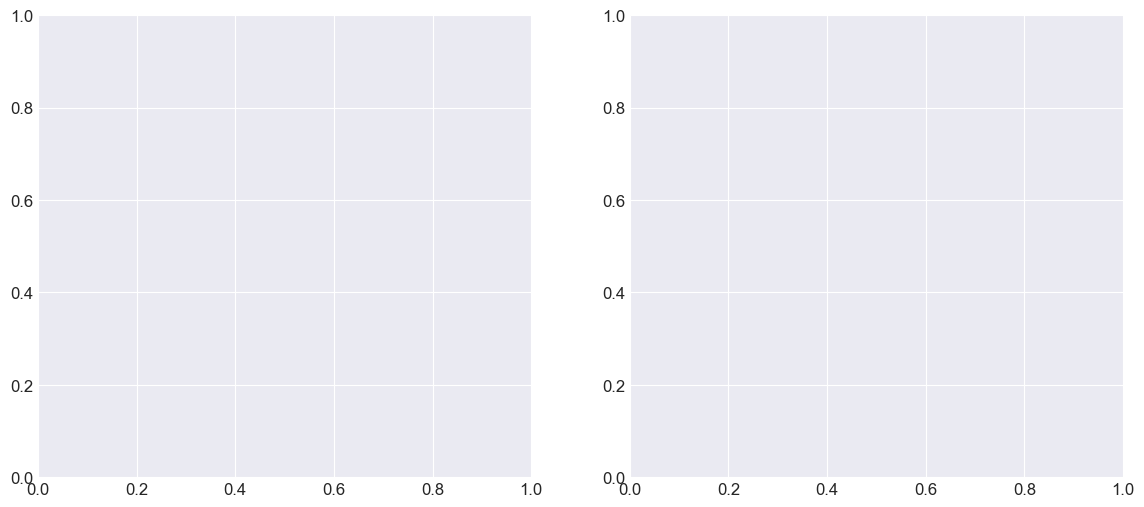

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*60)

# -----------------------------------------------------------------
# 1. Распределение языков в финальном датасете
# -----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Столбчатая диаграмма
lang_counts = df_augmented['Language'].value_counts()
sns.barplot(x=lang_counts.index, y=lang_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Распределение записей по языкам', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Язык')
axes[0].set_ylabel('Количество записей')
for i, v in enumerate(lang_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Круговая диаграмма
axes[1].pie(lang_counts.values, labels=lang_counts.index, autopct='%1.1f%%', 
            startangle=90, explode=[0.05]*len(lang_counts))
axes[1].set_title('Доля языков в датасете', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('language_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("График 1 сохранён: language_distribution.png")

# -----------------------------------------------------------------
# 2. Сравнение качества моделей (до и после обогащения)
# -----------------------------------------------------------------
if 'results' in dir() and 'results_after' in dir():
    fig, ax = plt.subplots(figsize=(10, 6))
    
    models_list = list(results.keys())
    before_scores = [results[m] for m in models_list]
    after_scores = [results_after[m] for m in models_list]
    
    x = range(len(models_list))
    width = 0.35
    
    bars1 = ax.bar([i - width/2 for i in x], before_scores, width, label='До обогащения', color='skyblue')
    bars2 = ax.bar([i + width/2 for i in x], after_scores, width, label='После обогащения', color='lightcoral')
    
    ax.set_ylabel('Accuracy')
    ax.set_title('Сравнение качества моделей до и после обогащения датасета', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=15)
    ax.legend()
    ax.set_ylim(0, 1)
    
    # Добавляем значения на столбцы
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('models_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("График 2 сохранён: models_comparison.png")

# -----------------------------------------------------------------
# 3. Матрица ошибок лучшей модели (на тестовой выборке)
# -----------------------------------------------------------------
if 'best_model' in dir() and 'X_test' in dir() and 'y_test' in dir():
    from sklearn.metrics import confusion_matrix
    
    y_pred_best = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_best)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=best_model.classes_, 
                yticklabels=best_model.classes_, ax=ax)
    ax.set_title(f'Матрица ошибок: {best_model_name}', fontweight='bold', fontsize=14)
    ax.set_xlabel('Предсказанный язык')
    ax.set_ylabel('Истинный язык')
    
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("График 3 сохранён: confusion_matrix.png")

# -----------------------------------------------------------------
# 4. Распределение уверенности классификатора на новых данных
# -----------------------------------------------------------------
if 'df_new' in dir() and 'confidence' in df_new.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Гистограмма уверенности
    axes[0].hist(df_new['confidence'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(x=0.8, color='green', linestyle='--', linewidth=2, label='Порог высокой уверенности (0.8)')
    axes[0].axvline(x=0.2, color='orange', linestyle='--', linewidth=2, label='Порог низкой уверенности (0.2)')
    axes[0].set_xlabel('Уверенность')
    axes[0].set_ylabel('Количество текстов')
    axes[0].set_title('Распределение уверенности классификатора\nна спарсенных данных')
    axes[0].legend()
    
    # Доля уверенных предсказаний по языкам
    df_new['high_conf'] = df_new['confidence'] > 0.8
    conf_by_lang = df_new.groupby('pred_lang')['high_conf'].mean() * 100
    
    bars = axes[1].bar(conf_by_lang.index, conf_by_lang.values, color='coral', edgecolor='black')
    axes[1].set_ylabel('% уверенных предсказаний (>0.8)')
    axes[1].set_title('Доля уверенных предсказаний по языкам')
    axes[1].set_ylim(0, 100)
    
    for bar, val in zip(bars, conf_by_lang.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("График 4 сохранён: confidence_distribution.png")

# -----------------------------------------------------------------
# 5. Топ-10 слов по языкам (из векторизатора)
# -----------------------------------------------------------------
if 'vectorizer' in dir():
    feature_names = vectorizer.get_feature_names_out()
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, lang in enumerate(best_model.classes_[:4]):  # максимум 4 языка
        # Получаем индекс класса
        class_idx = list(best_model.classes_).index(lang)
        
        # Для линейных моделей можно получить веса признаков
        if hasattr(best_model, 'coef_'):
            coef = best_model.coef_[class_idx]
            top_idx = np.argsort(coef)[-10:][::-1]
            top_words = [feature_names[i] for i in top_idx]
            top_scores = [coef[i] for i in top_idx]
            
            axes[idx].barh(top_words, top_scores, color='teal')
            axes[idx].set_title(f'Топ-10 значимых слов: {lang}', fontweight='bold')
            axes[idx].set_xlabel('Вес признака')
    
    plt.tight_layout()
    plt.savefig('top_words_by_language.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("График 5 сохранён: top_words_by_language.png")

# -----------------------------------------------------------------
# 6. Облако слов для каждого языка (из собранных данных)
# -----------------------------------------------------------------
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, lang in enumerate(df_augmented['Language'].unique()[:4]):
    # Собираем тексты для языка
    texts = df_augmented[df_augmented['Language'] == lang]['clean_text'].tolist()
    if not texts:
        continue
    all_text = ' '.join(texts)
    
    # Генерируем облако слов
    wordcloud = WordCloud(width=400, height=300, background_color='white', 
                          colormap='viridis', max_words=100).generate(all_text)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'Облако слов: {lang}', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('wordclouds_by_language.png', dpi=150, bbox_inches='tight')
plt.show()
print("График 6 сохранён: wordclouds_by_language.png")

# -----------------------------------------------------------------
# 7. Длина текстов по языкам (ящик с усами)
# -----------------------------------------------------------------
df_augmented['text_length'] = df_augmented['clean_text'].apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_augmented, x='Language', y='text_length', palette='Set3', ax=ax)
ax.set_title('Распределение длины текстов (количество слов) по языкам', fontweight='bold')
ax.set_ylabel('Количество слов')
ax.set_xlabel('Язык')

plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("График 7 сохранён: text_length_distribution.png")

# -----------------------------------------------------------------
# ИТОГОВЫЙ ОТЧЁТ
# -----------------------------------------------------------------
print("ИТОГОВЫЙ ОТЧЁТ ПО ПРОЕКТУ")

print(f"\nДАННЫЕ:")
print(f"   - Исходный датасет: {len(df_original) if 'df_original' in dir() else 0} записей")
print(f"   - Добавлено из парсинга: {len(df_new) if 'df_new' in dir() else 0} записей")
print(f"   - Финальный датасет: {len(df_augmented)} записей")
print(f"   - Распределение: {dict(df_augmented['Language'].value_counts())}")

print(f"\nМОДЕЛИ:")
for name, acc in results.items():
    print(f"   - {name}: accuracy = {acc:.4f}")

print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model_name} (accuracy = {results.get(best_model_name, 0):.4f})")

print(f"\nСОХРАНЁННЫЕ ФАЙЛЫ:")
print(f"   - augmented_language_dataset.csv (датасет)")
print(f"   - best_model_latest.pkl (модель)")
print(f"   - vectorizer_latest.pkl (векторизатор)")
print(f"   - *.png (графики визуализации)")